In [38]:
import sys
sys.path.append("..")

from src.data_loader import load_data, split_data
from pathlib import Path
from sklearn.decomposition import PCA
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
from src.models.classifier import build_svm_classifier, build_rf_classifier

In [39]:
data = load_data(Path("../data/"))

In [40]:
train_data, _ = split_data(data, split_after_batch=6)
X_train, y_train = train_data.select(pl.exclude("label", "concentration", "batch_id")).to_numpy(), train_data["label"].to_numpy()

In [41]:
pca = PCA()
pca.fit(X_train)

cov = pca.explained_variance_ratio_

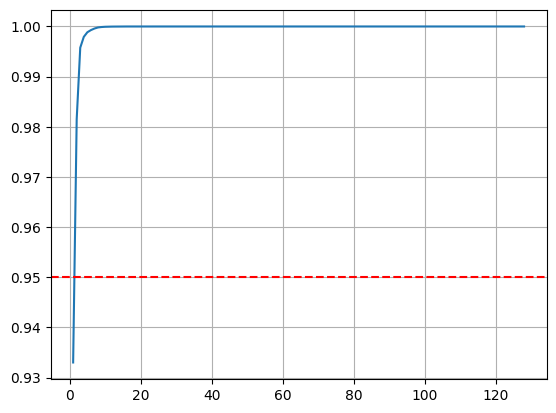

In [42]:
plt.plot(np.arange(1, len(cov) + 1), np.cumsum(cov))
plt.axhline(y=0.95, color="red", linestyle="--", label="95% variance")
plt.grid(True)
plt.show()

In [44]:
n_components = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 50]

batch_data = data.filter(pl.col("batch_id") == 7)
X_eval, y_eval = batch_data.select(pl.exclude("label", "concentration", "batch_id")).to_numpy(), batch_data["label"].to_numpy()

for n in n_components:
    model = build_svm_classifier(n_components=n)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_eval)
    score = f1_score(y_eval, y_pred, average="macro")
    print(score)

0.20915210151145006
0.2571272594248482
0.2657299912495115
0.4569218327871469
0.5514009856437115
0.6028218736817055
0.6450292658009106
0.6470790624434942
0.655241686172475
0.654306727664265
0.6564374148084918
0.6564374148084918


PCA explained variance analysis shows that a single component captures ~98% of variance, suggesting highly correlated sensor readings. However, classification F1 on batch 7 reveals that n_components=1 yields F1=0.21, while n_components=10 achieves F1=0.65, identical to n_components=20 and n_components=50. Additional components beyond 10 contribute no discriminative information. Selected: n_components=10.